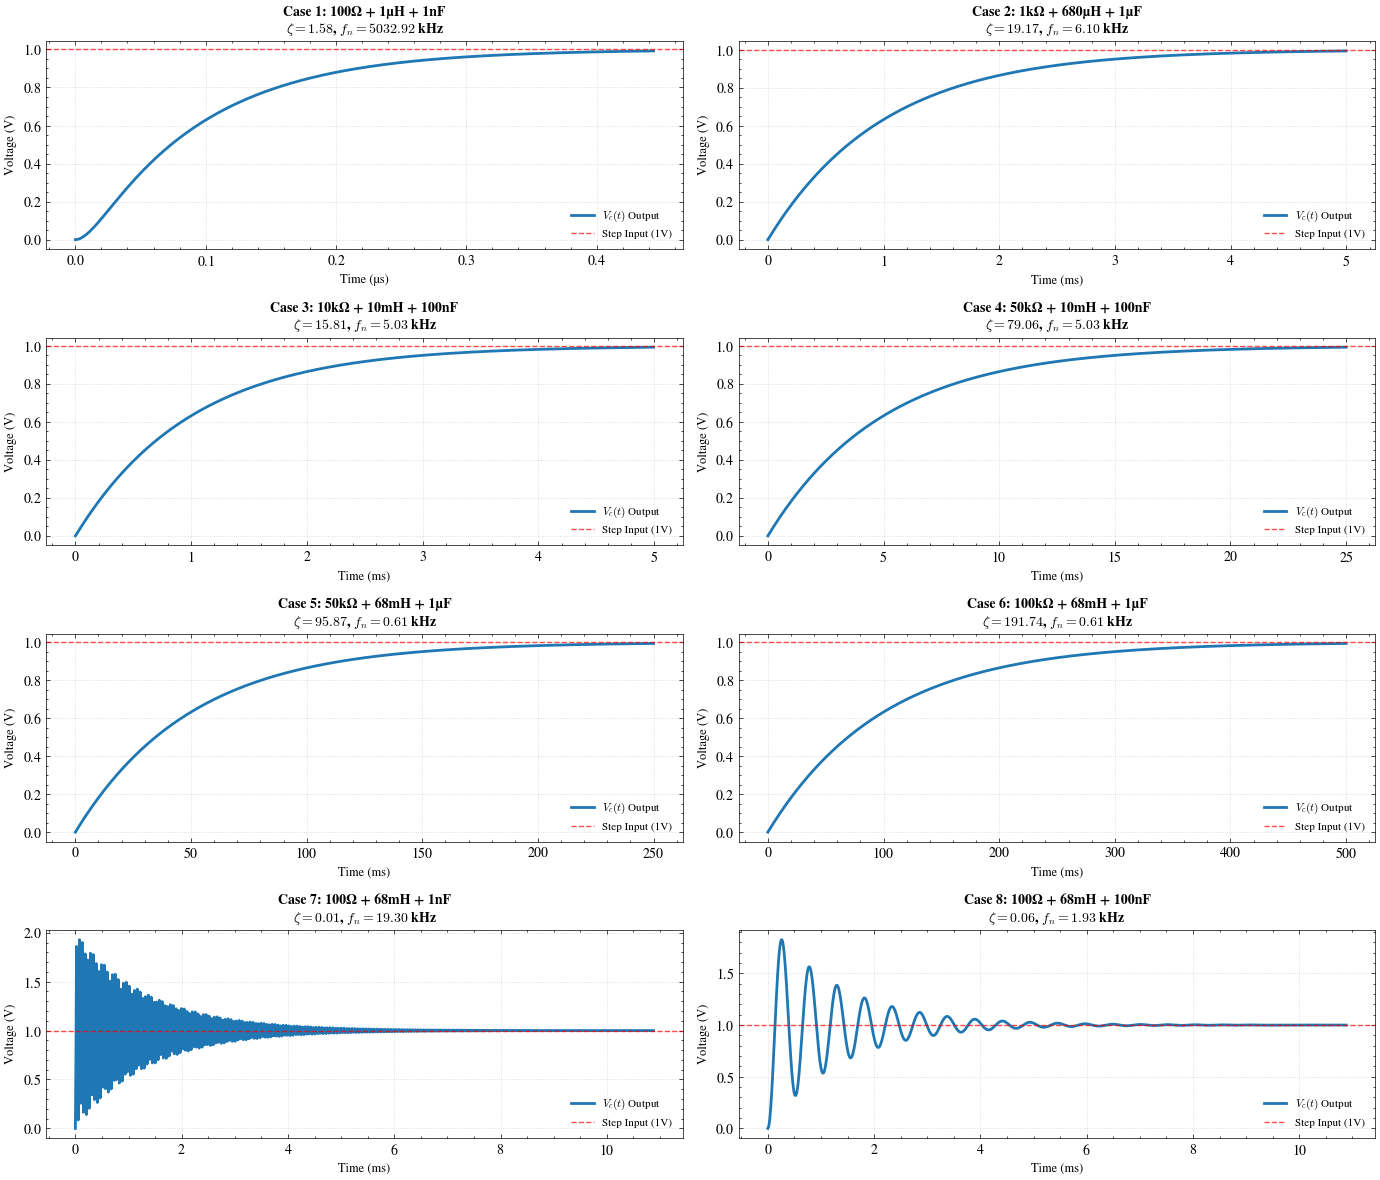

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

# Define the 8 component combinations: (R in Ohms, L in Henries, C in Farads, Title)
cases = [
    (100, 1e-6, 1e-9, "Case 1: 100Ω + 1µH + 1nF"),
    (1000, 680e-6, 1e-6, "Case 2: 1kΩ + 680µH + 1µF"),
    (10000, 10e-3, 100e-9, "Case 3: 10kΩ + 10mH + 100nF"),
    (50000, 10e-3, 100e-9, "Case 4: 50kΩ + 10mH + 100nF"),
    (50000, 68e-3, 1e-6, "Case 5: 50kΩ + 68mH + 1µF"),
    (100000, 68e-3, 1e-6, "Case 6: 100kΩ + 68mH + 1µF"),
    (100, 68e-3, 1e-9, "Case 7: 100Ω + 68mH + 1nF"),
    (100, 68e-3, 100e-9, "Case 8: 100Ω + 68mH + 100nF"),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (R, L, C, title) in enumerate(cases):
    # Calculate natural frequency and damping ratio
    wn = 1.0 / np.sqrt(L * C)
    zeta = (R / 2.0) * np.sqrt(C / L)
    fn = wn / (2 * np.pi)
    
    # Second-order Transfer Function: H(s) = wn^2 / (s^2 + 2*zeta*wn*s + wn^2)
    num = [wn**2]
    den = [1, 2 * zeta * wn, wn**2]
    sys = signal.TransferFunction(num, den)
    
    # Adaptive time array based on dominant time constant
    if zeta < 1:
        # Underdamped settling time
        t_max = 8 / (zeta * wn)
    else:
        # Overdamped dominant pole duration
        pole_dom = wn * (zeta - np.sqrt(zeta**2 - 1))
        t_max = 5 / pole_dom
        
    t = np.linspace(0, t_max, 1000)
    t_step, y_step = signal.step(sys, T=t)
    
    # Plot formatting
    ax = axes[i]
    time_factor = 1e6 if t_max < 1e-3 else 1e3
    time_unit = "µs" if t_max < 1e-3 else "ms"
    
    ax.plot(t_step * time_factor, y_step, color='#1f77b4', linewidth=2, label='$V_c(t)$ Output')
    ax.axhline(1.0, color='r', linestyle='--', alpha=0.7, label='Step Input (1V)')
    
    ax.set_title(f"{title}\n$\\zeta={zeta:.2f}$, $f_n={fn/1e3:.2f}$ kHz", fontsize=10, fontweight='bold')
    ax.set_xlabel(f"Time ({time_unit})", fontsize=9)
    ax.set_ylabel("Voltage (V)", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

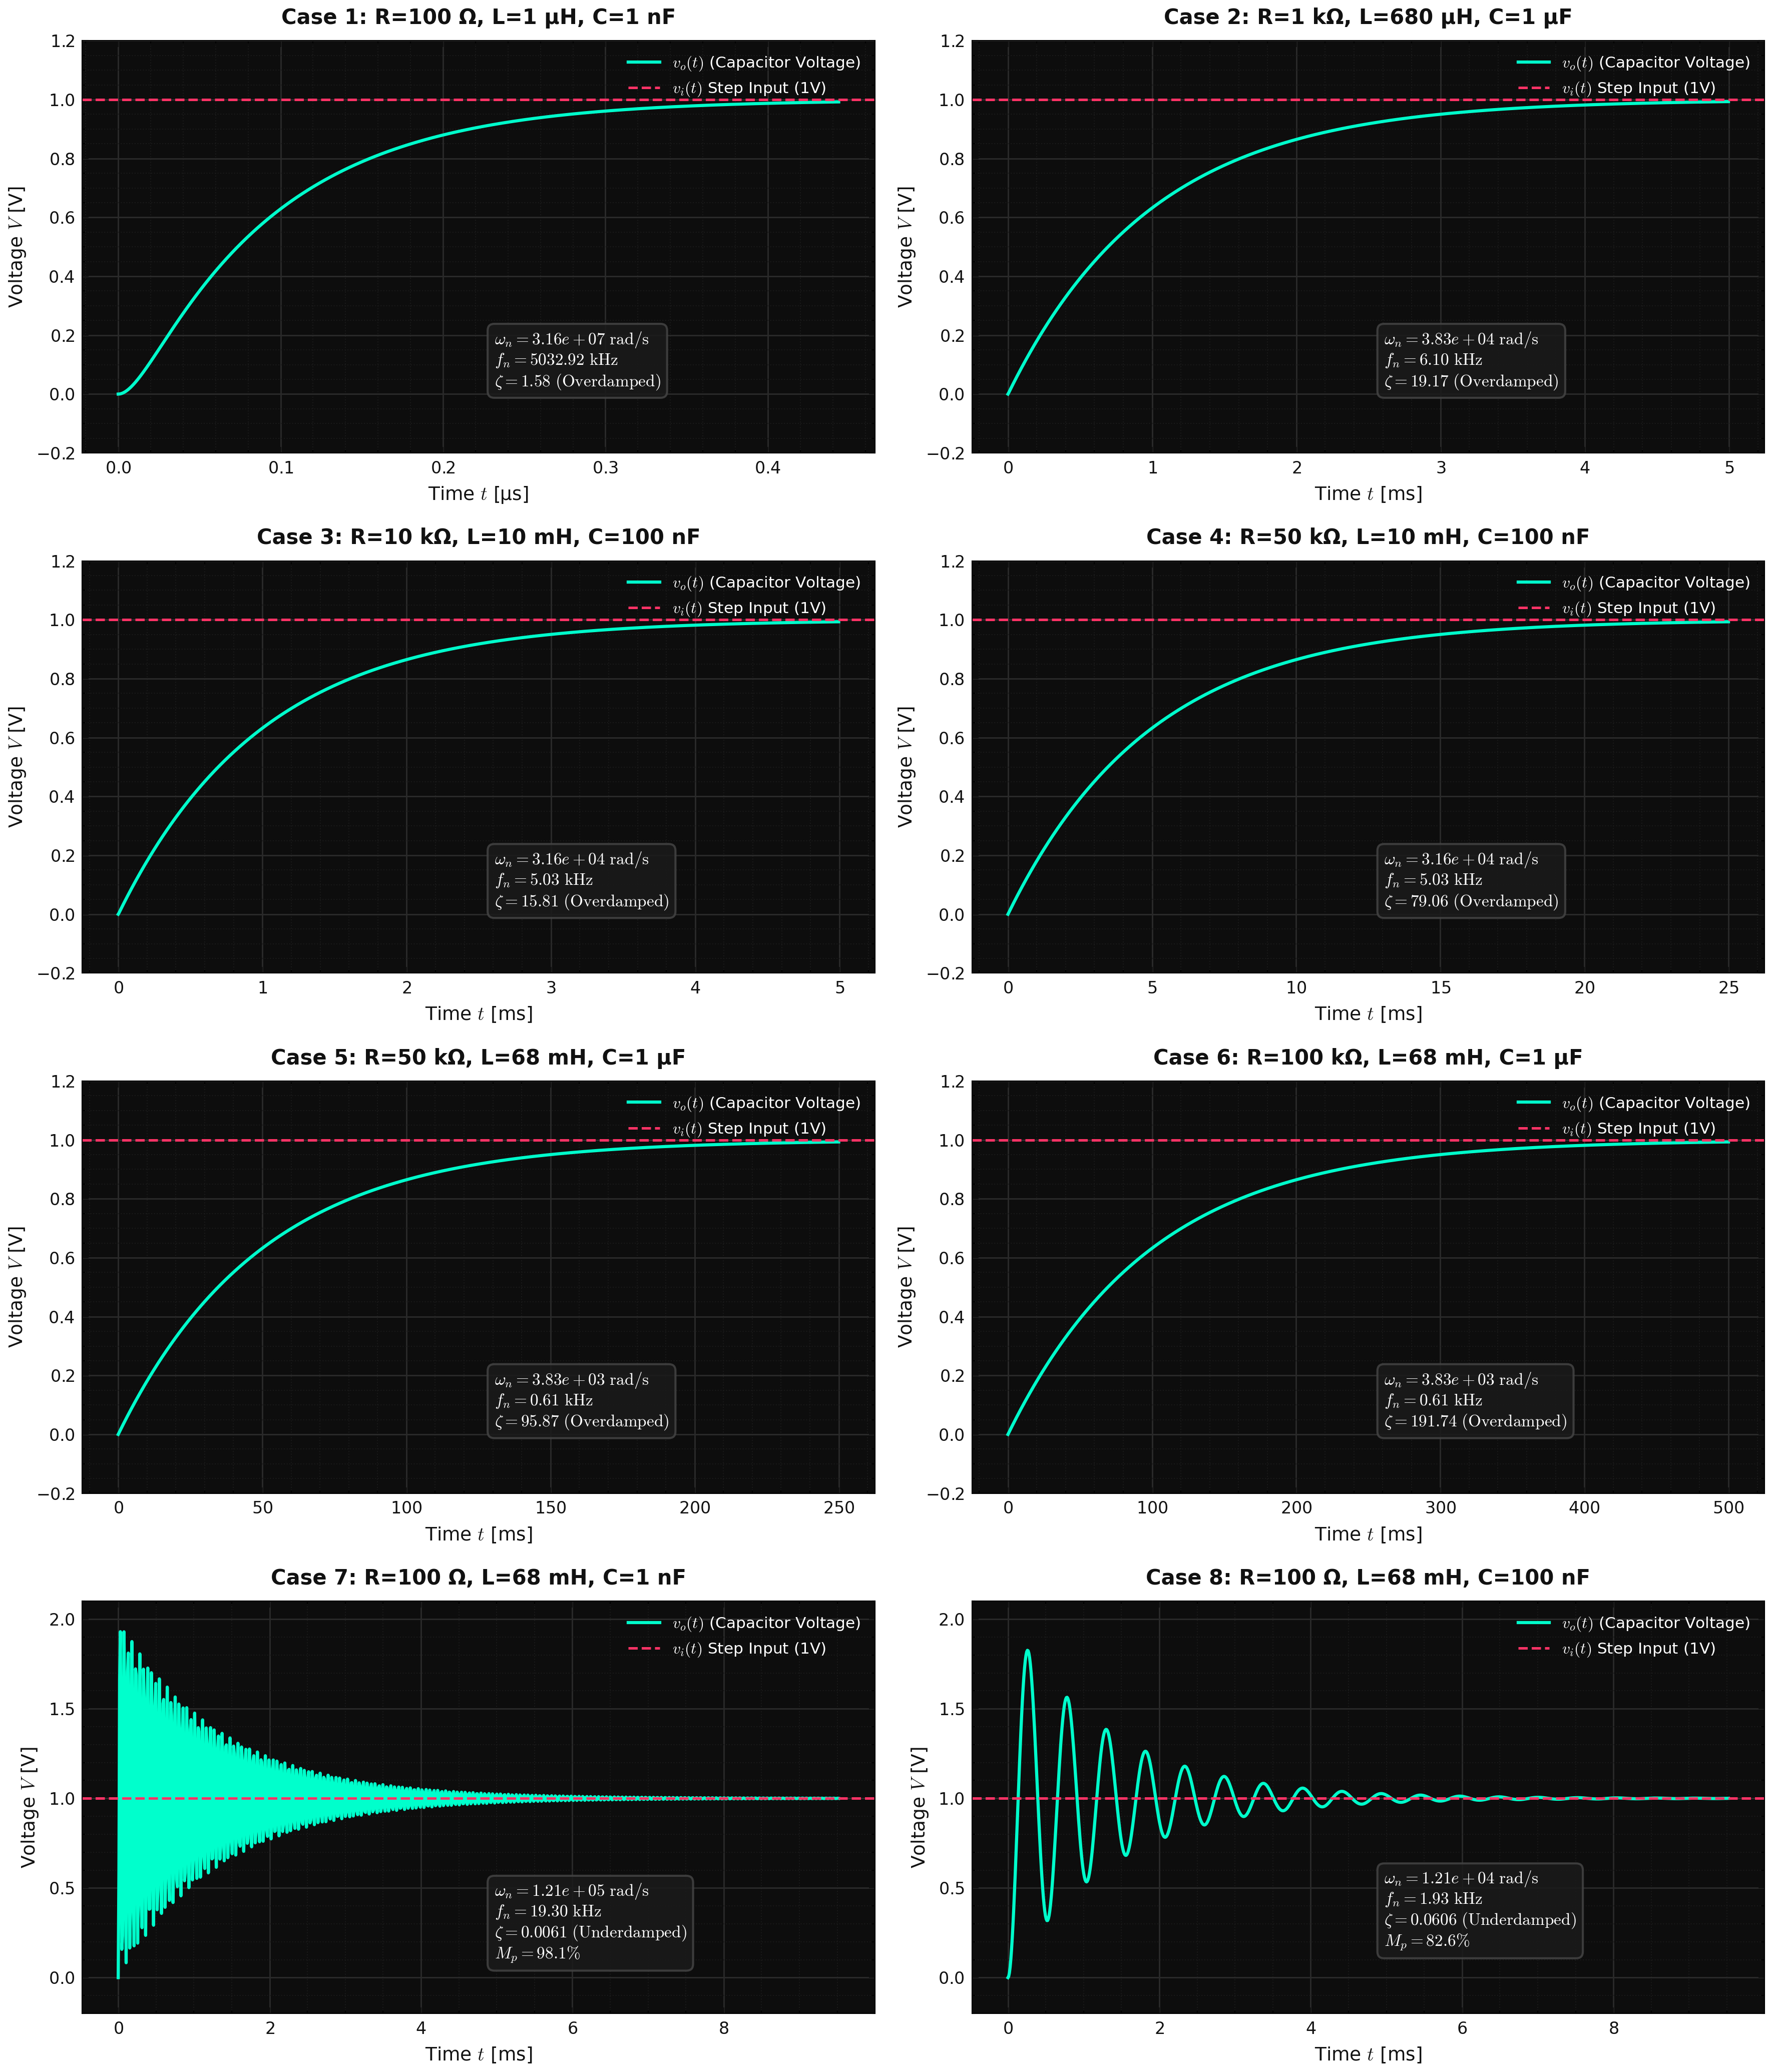

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

# Set up global plot parameters for engineering notation
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['mathtext.fontset'] = 'cm'

# Test Cases: (R [Ω], L [H], C [F], Label)
cases = [
    (100, 1e-6, 1e-9, "Case 1: R=100 Ω, L=1 µH, C=1 nF"),
    (1000, 680e-6, 1e-6, "Case 2: R=1 kΩ, L=680 µH, C=1 µF"),
    (10000, 10e-3, 100e-9, "Case 3: R=10 kΩ, L=10 mH, C=100 nF"),
    (50000, 10e-3, 100e-9, "Case 4: R=50 kΩ, L=10 mH, C=100 nF"),
    (50000, 68e-3, 1e-6, "Case 5: R=50 kΩ, L=68 mH, C=1 µF"),
    (100000, 68e-3, 1e-6, "Case 6: R=100 kΩ, L=68 mH, C=1 µF"),
    (100, 68e-3, 1e-9, "Case 7: R=100 Ω, L=68 mH, C=1 nF"),
    (100, 68e-3, 100e-9, "Case 8: R=100 Ω, L=68 mH, C=100 nF"),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 14), dpi=300)
axes = axes.flatten()

for i, (R, L, C, title) in enumerate(cases):
    # Control System Calculations
    wn = 1.0 / np.sqrt(L * C)
    zeta = (R / 2.0) * np.sqrt(C / L)
    fn = wn / (2 * np.pi)
    
    # Transfer Function H(s) = wn^2 / (s^2 + 2*zeta*wn*s + wn^2)
    num = [wn**2]
    den = [1, 2 * zeta * wn, wn**2]
    sys = signal.TransferFunction(num, den)
    
    # Adaptive time windowing
    if zeta < 1:
        t_max = 7 / (zeta * wn)
    else:
        pole_dom = wn * (zeta - np.sqrt(zeta**2 - 1))
        t_max = 5 / pole_dom
        
    t = np.linspace(0, t_max, 1000)
    t_step, y_step = signal.step(sys, T=t)
    
    ax = axes[i]
    
    # Unit scaling
    time_factor = 1e6 if t_max < 1e-3 else (1e3 if t_max < 1 else 1)
    time_unit = "µs" if t_max < 1e-3 else ("ms" if t_max < 1 else "s")
    
    # Oscilloscope Grid Styling
    ax.set_facecolor('#0d0d0d')  # CRT display background
    ax.grid(True, which='major', color='#2a2a2a', linestyle='-', linewidth=0.7)
    ax.grid(True, which='minor', color='#1a1a1a', linestyle=':', linewidth=0.5)
    ax.minorticks_on()
    
    # Signal traces
    ax.plot(t_step * time_factor, y_step, color='#00ffcc', linewidth=1.5, label=r'$v_o(t)$ (Capacitor Voltage)')
    ax.axhline(1.0, color='#ff3366', linestyle='--', linewidth=1.2, label=r'$v_i(t)$ Step Input (1V)')
    
    # In-plot Data Telemetry Box
    if zeta < 1:
        wd = wn * np.sqrt(1 - zeta**2)
        mp = np.exp(-zeta * np.pi / np.sqrt(1 - zeta**2)) * 100
        textstr = '\n'.join((
            r'$\omega_n = %.2e\ \mathrm{rad/s}$' % (wn,),
            r'$f_n = %.2f\ \mathrm{kHz}$' % (fn/1e3,),
            r'$\zeta = %.4f\ \mathrm{(Underdamped)}$' % (zeta,),
            r'$M_p = %.1f\%%$' % (mp,),
        ))
    else:
        textstr = '\n'.join((
            r'$\omega_n = %.2e\ \mathrm{rad/s}$' % (wn,),
            r'$f_n = %.2f\ \mathrm{kHz}$' % (fn/1e3,),
            r'$\zeta = %.2f\ \mathrm{(Overdamped)}$' % (zeta,),
        ))
        
    props = dict(boxstyle='round,pad=0.4', facecolor='#1a1a1a', alpha=0.85, edgecolor='#444444')
    ax.text(0.52, 0.12 if zeta < 1 and i==6 else 0.15, textstr, transform=ax.transAxes, fontsize=8,
            verticalalignment='bottom', bbox=props, color='#ffffff', family='monospace')
    
    # Labeling
    ax.set_title(title, fontsize=10, fontweight='bold', color='#111111', pad=8)
    ax.set_xlabel(f'Time $t$ [{time_unit}]', fontsize=9, color='#111111')
    ax.set_ylabel('Voltage $V$ [V]', fontsize=9, color='#111111')
    ax.set_ylim(-0.2, 2.1 if zeta < 1 else 1.2)
    
    ax.tick_params(colors='#111111', labelsize=8)
    ax.legend(loc='upper right', fontsize=7.5, facecolor='#1a1a1a', edgecolor='#444444', labelcolor='#ffffff')

plt.tight_layout()
plt.savefig("engineering_rlc_step_responses.png", dpi=300)
plt.show()